In [39]:
import numpy as np
import pandas  as pd
import matplotlib.pyplot as plt
import sklearn as sklearn
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

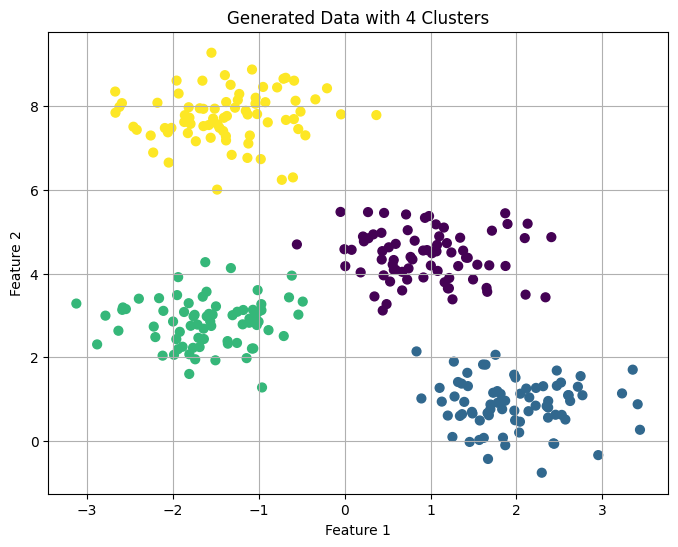

In [40]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Generate the data
data, labels = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

# Plot it
plt.figure(figsize=(8, 6))
plt.scatter(data[:, 0], data[:, 1], c=labels, s=40, cmap='viridis')
plt.title("Generated Data with 4 Clusters")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()


In [ ]:
X = pd.DataFrame(data[0])
y = pd.Series(data[1])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

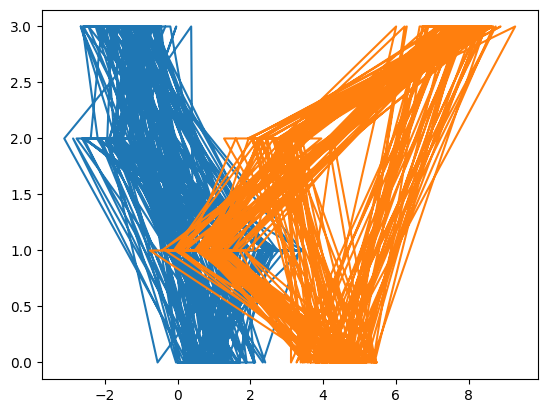

In [37]:
plt.plot(X,y)

In [15]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((240, 2), (240,), (60, 2), (60,))

In [17]:
X_train.describe()

,0,1
count,240.000000,240.000000
mean,0.025889,3.907141
std,1.622033,2.613398
min,-3.122407,-0.765892
25%,-1.487069,1.665166
50%,0.200352,3.467808
75%,1.461779,5.604414
max,3.410853,9.282932


In [18]:
y_train.describe()

count    240.000000
mean       1.495833
std        1.112868
min        0.000000
25%        1.000000
50%        1.000000
75%        2.250000
max        3.000000
dtype: float64

In [20]:
X_train.head(10)

,0,1
232,0.728099,3.855314
59,1.392638,0.928963
6,-1.808223,1.597017
185,1.432893,4.376792
173,1.895938,5.185403
30,-0.513333,7.874374
22,0.734364,5.037254
256,-0.614907,3.949636
56,-0.041502,7.808703
186,1.062696,5.176351


In [26]:
X_train_std = StandardScaler().fit_transform(X_train)
X_test_std = StandardScaler().fit_transform(X_test)

In [27]:
X_train_std

array([[ 0.43382418, -0.01987238],
       [ 0.84437549, -1.14196235],
       [-1.13311211, -0.88580122],
       [ 0.8692451 ,  0.18008482],
       [ 1.1553137 ,  0.49014101],
       [-0.33313114,  1.52120896],
       [ 0.43769482,  0.43333457],
       [-0.39588323,  0.01629453],
       [-0.04163408,  1.49602788],
       [ 0.64053814,  0.4866704 ],
       [-0.82812144,  1.12421724],
       [ 1.01746282, -1.24536249],
       [ 0.60410591,  0.10902691],
       [ 0.32968225,  0.11766573],
       [-1.09032369, -0.75122019],
       [ 1.00949642, -0.13199987],
       [ 0.77451224, -1.09252444],
       [-0.60231114,  1.74739052],
       [-1.5346055 ,  1.38217762],
       [-0.83574431,  1.76697091],
       [ 0.99721898, -0.80049567],
       [ 0.95225024, -1.49133811],
       [-0.68234661, -0.65286026],
       [ 0.86629375, -0.87532043],
       [-0.65566397,  1.64821238],
       [ 1.11689947, -1.20903676],
       [ 0.97960684, -0.79896859],
       [-0.6567677 ,  1.59353697],
       [ 0.2643577 ,

In [28]:
model = KMeans(n_clusters=4)
model.fit(X_train_std)
y_pred = model.predict(X_test_std)
loss = silhouette_score(X_test_std, y_pred)

In [31]:
y_pred

array([2, 0, 1, 1, 3, 0, 2, 0, 3, 1, 2, 2, 3, 2, 2, 3, 0, 2, 1, 2, 3, 1,
       1, 0, 0, 0, 3, 3, 2, 1, 3, 0, 1, 2, 2, 0, 0, 0, 1, 2, 2, 2, 1, 1,
       0, 2, 2, 0, 2, 1, 3, 0, 2, 1, 0, 1, 3, 1, 0, 0], dtype=int32)

In [32]:
y_test

203    2
266    0
152    3
9      3
233    1
226    0
196    2
109    0
5      1
175    3
237    2
57     2
218    1
45     2
182    2
221    1
289    0
211    2
148    3
165    2
78     1
113    3
249    3
250    0
104    0
42     0
281    1
295    1
157    2
238    3
17     1
164    0
33     3
24     2
215    2
119    0
7      0
90     0
46     3
73     2
93     2
76     2
286    3
60     3
77     0
63     2
234    2
229    0
111    2
231    3
180    1
144    0
239    2
75     3
297    0
278    3
97     1
92     3
192    0
25     0
dtype: int64

# Kmean on image

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from PIL import Image

In [47]:
# Load image (change path as needed)
img = Image.open("/media/guru/e3dd0686-a58b-467b-913b-60b095056804/Deep_Gen_AI/popular-flower-types-dahlia.jpg")
img = img.convert('RGB')  # Ensure it's in RGB format
img_np = np.array(img)

# Optional: Resize for faster processing
img_small = img.resize((100, 100))
img_small_np = np.array(img_small)


In [48]:
# Reshape the image data into (n_samples, 3) where 3 = R,G,B
pixels = img_small_np.reshape(-1, 3)

In [49]:
# Apply KMeans to color clustering
kmeans = KMeans(n_clusters=10, random_state=0)
kmeans.fit(pixels)

# Get clustered labels and recreate clustered image
clustered_pixels = kmeans.cluster_centers_[kmeans.labels_]
clustered_img = clustered_pixels.reshape(img_small_np.shape).astype(np.uint8)


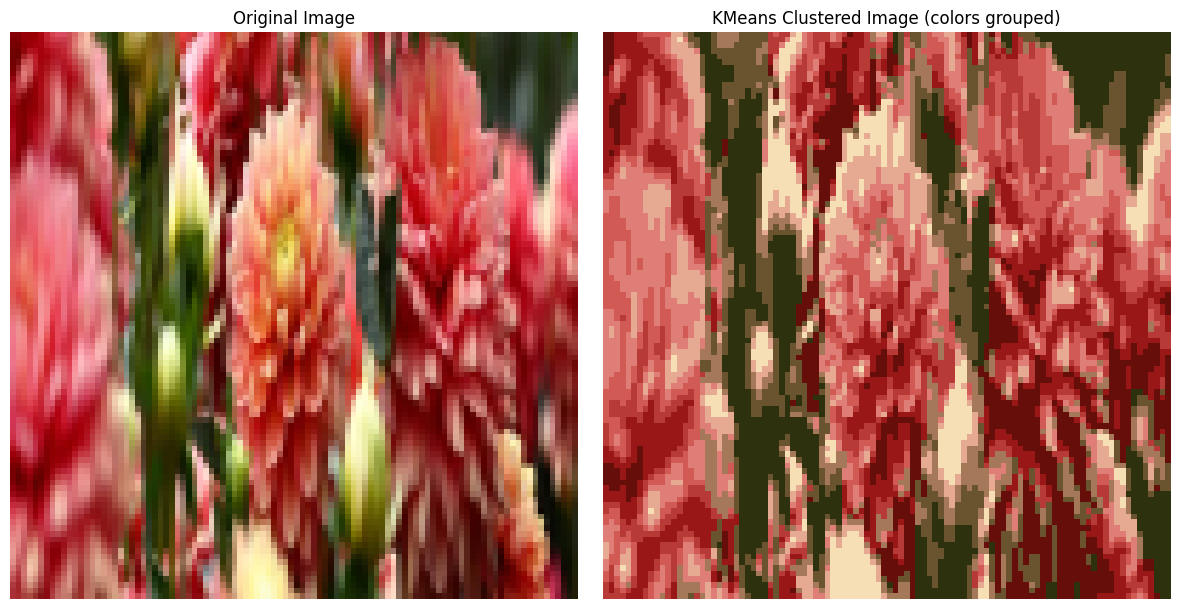

In [50]:
# Show images
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(img_small_np)
ax[0].set_title("Original Image")
ax[0].axis('off')

ax[1].imshow(clustered_img)
ax[1].set_title("KMeans Clustered Image (colors grouped)")
ax[1].axis('off')

plt.tight_layout()
plt.show()


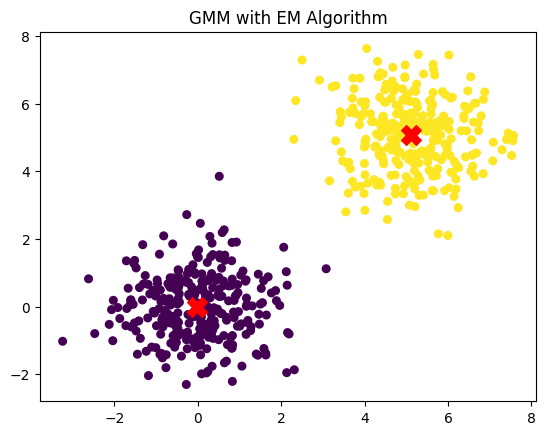

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Generate synthetic 2D data
np.random.seed(42)
n_samples = 300
mu1, sigma1 = [0, 0], [[1, 0], [0, 1]]
mu2, sigma2 = [5, 5], [[1, 0], [0, 1]]
X = np.vstack([
    np.random.multivariate_normal(mu1, sigma1, n_samples),
    np.random.multivariate_normal(mu2, sigma2, n_samples)
])

# Initialize parameters
K = 2  # number of Gaussians
n, d = X.shape
pi = np.ones(K) / K
mu = X[np.random.choice(n, K, replace=False)]
sigma = [np.eye(d) for _ in range(K)]

def gaussian_pdf(x, mean, cov):
    return multivariate_normal.pdf(x, mean=mean, cov=cov)

# EM Algorithm
for iteration in range(20):
    # ---- E-Step ----
    gamma = np.zeros((n, K))
    for k in range(K):
        gamma[:, k] = pi[k] * gaussian_pdf(X, mu[k], sigma[k])
    gamma = gamma / gamma.sum(axis=1, keepdims=True)
    
    # ---- M-Step ----
    Nk = gamma.sum(axis=0)
    for k in range(K):
        mu[k] = (1 / Nk[k]) * np.sum(gamma[:, k].reshape(-1, 1) * X, axis=0)
        sigma[k] = (1 / Nk[k]) * ((X - mu[k]).T @ (gamma[:, k].reshape(-1, 1) * (X - mu[k])))
        pi[k] = Nk[k] / n

# Final cluster assignment
labels = np.argmax(gamma, axis=1)

# Plot results
plt.scatter(X[:, 0], X[:, 1], c=labels, s=30, cmap='viridis')
plt.scatter(mu[:, 0], mu[:, 1], c='red', s=200, marker='X')  # final means
plt.title("GMM with EM Algorithm")
plt.show()
